# Segmentación de Instancias y Tracking — CPU vs GPU + SAM3
| IA 5.2 Computer Vision
| FCEIA - UNR

En esta práctica trabajamos con **YOLO11-seg**, un modelo de **segmentación de instancias**
(devuelve una máscara por objeto, no solo una caja), le sumamos **tracking multi-objeto**
para seguir cada objeto a lo largo de un video, y al final lo comparamos contra **SAM3**.

Recorremos cinco bloques que se construyen uno sobre otro:

| # | Bloque | Pregunta que responde |
|---|---|---|
| 1 | **Segmentación** | ¿Qué objetos hay en el frame y qué píxeles ocupa cada uno? |
| 2 | **Benchmark CPU vs GPU** | ¿Cuánto tarda? ¿Cuánto acelera la GPU? |
| 3 | **Tracking** | ¿Es "el mismo" objeto entre frames? (ID persistente) |
| 4 | **SAM3** | ¿Qué pasa con un modelo de segmentación de altísima calidad? |
| 5 | **Comparación final** | YOLO11 vs SAM3: velocidad y cantidad de máscaras |

> **Repaso de la teoría (Unidad 6).** El tracker no "ve" el video: en cada frame predice dónde
> debería estar cada objeto con un **filtro de Kalman** y asocia esas predicciones con las
> detecciones nuevas resolviendo un problema de asignación con el **algoritmo Húngaro**.
> Sobre esa base, **ByteTrack** usa solo movimiento (rápido) y **BoT-SORT** agrega apariencia
> (ReID) y compensación de cámara (más robusto, más lento).

---
## Instalación

In [46]:
# Ejecutar una sola vez
# !pip install ultralytics gdown -q

## Librerías

In [47]:
import time
import numpy as np
import pandas as pd
import cv2
import torch
import psutil
import matplotlib.pyplot as plt
from ultralytics import YOLO

print(f"PyTorch: {torch.__version__}")
HAS_CUDA = torch.cuda.is_available()
print(f"CUDA disponible: {HAS_CUDA}")
if HAS_CUDA:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Dispositivos que vamos a comparar (si no hay GPU, solo CPU)
DEVICES = {"CPU": "cpu"}
if HAS_CUDA:
    DEVICES["GPU"] = 0
print("Dispositivos a evaluar:", list(DEVICES.keys()))

PyTorch: 2.10.0+cpu
CUDA disponible: False
Dispositivos a evaluar: ['CPU']


## Descargar el video

Usamos el mismo video que la teoría (una calle de Shinjuku, con autos y personas).

> Si la descarga falla, podés usar **cualquier** video propio: solo cambiá `VIDEO_PATH`.

In [48]:
import gdown

VIDEO_PATH = "shinjuku.mp4"
file_id = "13d-WecRvyTozDcQrHxLV1t_e5GQzPiPz"   # mismo video que la teoría
gdown.download(f"https://drive.google.com/uc?id={file_id}", VIDEO_PATH, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=13d-WecRvyTozDcQrHxLV1t_e5GQzPiPz
To: c:\Users\const\Documents\Trabajo\Facultad\CV\IA5.2_Computer_Vision\unidad_6\practica\segmentacion_tracking\shinjuku.mp4
100%|██████████| 2.84M/2.84M [00:00<00:00, 17.0MB/s]


'shinjuku.mp4'

In [49]:
cap = cv2.VideoCapture(VIDEO_PATH)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS_SRC = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f"{VIDEO_PATH}: {W}x{H} | {TOTAL_FRAMES} frames | {FPS_SRC:.0f} FPS")

# Para que la práctica sea rápida procesamos solo un tramo del video.
# En CPU usamos pocos frames porque la inferencia es ~10-40x más lenta que en GPU
# (con 50 frames en CPU, la celda de tracking puede tardar varios minutos).
N_FRAMES = 50 if HAS_CUDA else 12
print(f"Procesaremos N_FRAMES = {N_FRAMES} frames  (HAS_CUDA={HAS_CUDA})")

shinjuku.mp4: 1280x606 | 631 frames | 30 FPS
Procesaremos N_FRAMES = 12 frames  (HAS_CUDA=False)


---
# 1. Segmentación de instancias

Conviene distinguir tres tareas que suelen confundirse:

| Tarea | Salida por objeto | Ejemplo de modelo |
|---|---|---|
| **Detección** | una **caja** (bbox) + clase | Faster R-CNN, YOLO |
| **Segmentación semántica** | una **clase por píxel** (no separa instancias) | DeepLab |
| **Segmentación de instancias** | una **máscara por objeto** + clase | YOLO11-seg, Mask R-CNN, SAM |

YOLO11-seg hace lo último: por cada objeto devuelve caja, clase, score **y** una máscara que
marca exactamente qué píxeles le pertenecen. Cargamos la variante **`yolo11n-seg`**
(`n` = *nano*, la más liviana y rápida) y la corremos sobre el primer frame.

Objetos segmentados en el frame: 5


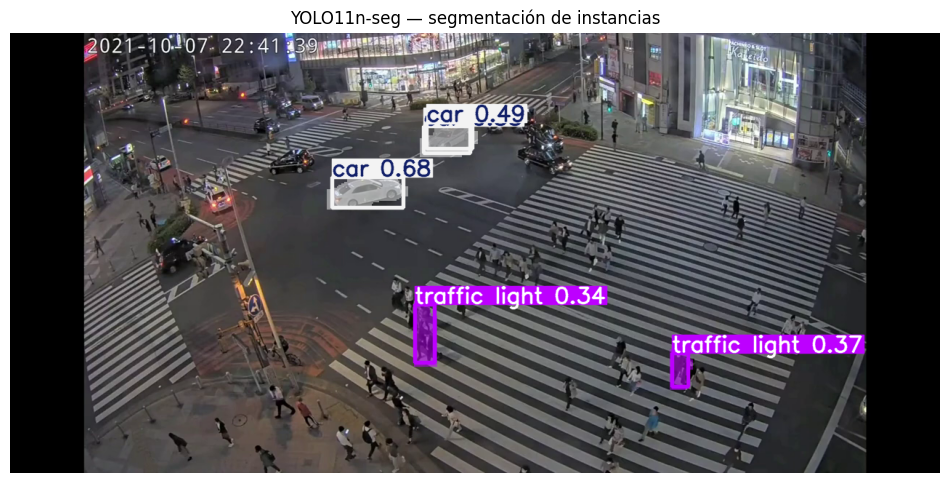

In [50]:
model = YOLO("yolo11n-seg.pt")   # se descarga solo la primera vez

# Tomamos el primer frame del video
cap = cv2.VideoCapture(VIDEO_PATH)
ok, frame = cap.read()
cap.release()

res = model(frame, conf=0.3, verbose=False)[0]
print(f"Objetos segmentados en el frame: {len(res.masks) if res.masks is not None else 0}")

# res.plot() dibuja máscaras + cajas + clases sobre el frame
vis = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 6))
plt.imshow(vis); plt.axis("off")
plt.title("YOLO11n-seg — segmentación de instancias")
plt.show()

## 1.1 ¿Qué hay dentro de un resultado?

Cada resultado de YOLO trae varios objetos que conviene conocer:

- `res.boxes.cls` — el **id de clase** de cada detección
- `res.boxes.conf` — el **score** (confianza)
- `res.masks.data` — las **máscaras** como tensor `(n_objetos, alto, ancho)`
- `res.names` — el diccionario `{id: nombre}` (clases de **COCO**, 80 categorías)

Veamos qué **clases** detectó y cuántas instancias de cada una, y comparemos la imagen
original contra la **unión de todas las máscaras** (esto deja en evidencia que la segmentación
razona a nivel de **píxel**, no de caja).

Instancias por clase:
car              3
traffic light    2


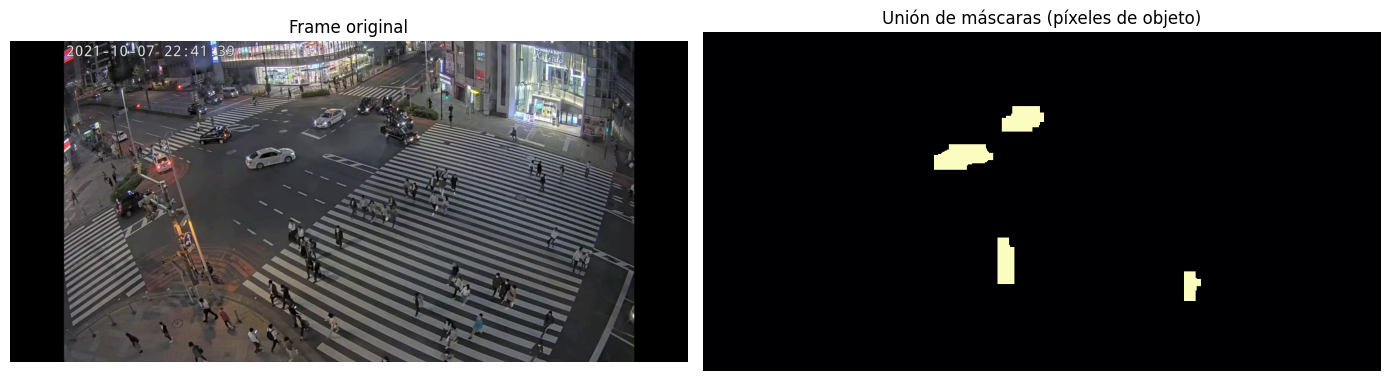

In [51]:
# Conteo de instancias por clase
clases = [res.names[int(c)] for c in res.boxes.cls]
conteo = pd.Series(clases).value_counts()
print("Instancias por clase:")
print(conteo.to_string())

# Unión de todas las máscaras del frame (0/1 por píxel)
mascaras = res.masks.data.cpu().numpy()      # (n, h, w)
union = mascaras.max(axis=0)                  # combinamos todas en una sola

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); axes[0].set_title("Frame original")
axes[1].imshow(union, cmap="magma"); axes[1].set_title("Unión de máscaras (píxeles de objeto)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

---
# 2. Benchmark: CPU vs GPU

Una idea clave: **el hardware no cambia lo que el modelo detecta, solo la velocidad**.
Los mismos pesos producen las mismas máscaras en CPU y en GPU; lo que cambia es cuántos
milisegundos tarda cada frame.

Medimos por dispositivo:
- **latencia por frame** (ms) y su **P95** (el "peor caso" típico, el percentil 95)
- **throughput** (FPS = 1000 / latencia media)
- **máscaras por frame** (para confirmar que la detección no depende del hardware)

In [52]:
def benchmark(model_name, device, n_frames=N_FRAMES, conf=0.3, imgsz=640):
    """Corre YOLO11-seg sobre n_frames y mide la latencia por frame."""
    model = YOLO(model_name)
    cap = cv2.VideoCapture(VIDEO_PATH)

    # Warm-up: la primera inferencia compila kernels y no es representativa
    ok, frame = cap.read()
    if ok:
        model(frame, device=device, imgsz=imgsz, verbose=False)

    lat_ms, n_masks = [], []
    for _ in range(n_frames):
        ok, frame = cap.read()
        if not ok:
            break
        t0 = time.perf_counter()
        r = model(frame, device=device, conf=conf, imgsz=imgsz, verbose=False)[0]
        lat_ms.append((time.perf_counter() - t0) * 1000)
        n_masks.append(len(r.masks) if r.masks is not None else 0)
    cap.release()

    lat = np.array(lat_ms)
    return {
        "lat_ms":     lat,
        "mean_ms":    float(lat.mean()),
        "p95_ms":     float(np.percentile(lat, 95)),
        "fps":        float(1000.0 / lat.mean()),
        "mean_masks": float(np.mean(n_masks)),
    }

In [53]:
results = {}
for label, device in DEVICES.items():
    print(f"Benchmark en {label} ...")
    results[label] = benchmark("yolo11n-seg.pt", device)
    r = results[label]
    print(f"  media={r['mean_ms']:6.1f} ms | P95={r['p95_ms']:6.1f} ms | "
          f"{r['fps']:5.1f} FPS | máscaras/frame={r['mean_masks']:.1f}")

Benchmark en CPU ...
  media=  86.3 ms | P95=  91.9 ms |  11.6 FPS | máscaras/frame=2.4


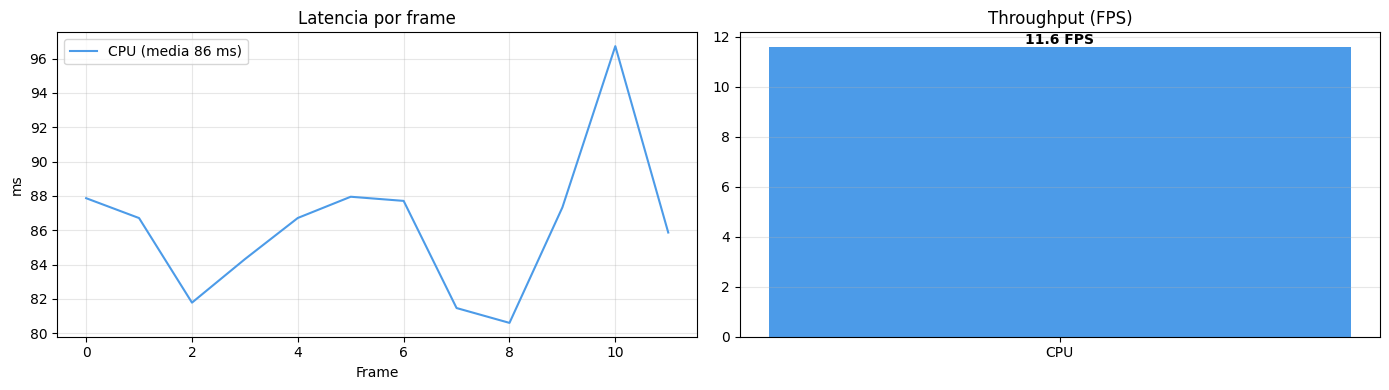

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
labels  = list(results.keys())
colores = {"CPU": "#4C9BE8", "GPU": "#F2A541"}

# Latencia por frame
for label in labels:
    axes[0].plot(results[label]["lat_ms"], color=colores.get(label),
                 label=f"{label} (media {results[label]['mean_ms']:.0f} ms)")
axes[0].set_title("Latencia por frame"); axes[0].set_xlabel("Frame")
axes[0].set_ylabel("ms"); axes[0].legend(); axes[0].grid(alpha=0.3)

# FPS comparativo
fps_vals = [results[l]["fps"] for l in labels]
bars = axes[1].bar(labels, fps_vals, color=[colores.get(l) for l in labels], width=0.5)
axes[1].bar_label(bars, fmt="%.1f FPS", fontweight="bold")
axes[1].set_title("Throughput (FPS)"); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()

In [55]:
# Tabla resumen
tabla = pd.DataFrame({
    label: {
        "Media (ms)":     round(r["mean_ms"], 1),
        "P95 (ms)":       round(r["p95_ms"], 1),
        "FPS":            round(r["fps"], 1),
        "Máscaras/frame": round(r["mean_masks"], 1),
    }
    for label, r in results.items()
}).T
if {"CPU", "GPU"}.issubset(results):
    tabla["Speedup vs CPU"] = (results["CPU"]["mean_ms"] /
                               tabla.index.map(lambda l: results[l]["mean_ms"])).round(1)
tabla

,Media (ms),P95 (ms),FPS,Máscaras/frame
CPU,86.3,91.9,11.6,2.4


#### Análisis

- **Las máscaras por frame son (casi) iguales en CPU y GPU**: el hardware no cambia *qué*
  se detecta, solo la velocidad. Pequeñas diferencias pueden venir de redondeos en FP16.
- En **GPU** el mismo modelo suele correr **entre 5× y 40× más rápido**: cuanto más grande
  la red, más se beneficia del paralelismo (lo vas a comprobar en el Ejercicio 1).
- La **P95** es interesante: en CPU suele ser bastante mayor que la media (latencia con "colas"
  largas en frames complejos), mientras que en GPU P95 ≈ media (mucho más predecible).

> **Si solo tenés CPU** (por ejemplo, corriendo localmente sin GPU) vas a ver un único color
> y sin columna de speedup. En Colab podés activar GPU en *Entorno de ejecución → Cambiar tipo*.

---
# 3. Tracking multi-objeto

Hasta acá detectamos objetos **frame por frame**, sin memoria: en el frame 10 no sabemos
si un auto es "el mismo" que vimos en el frame 9.

El **tracking** resuelve eso asignando un **ID persistente** a cada objeto. Con
`model.track(..., persist=True)` Ultralytics aplica internamente el ciclo que vimos en teoría:

```
detección (YOLO) → predicción (Kalman) → asociación (algoritmo Húngaro) → actualizar IDs
```

## 3.1 ByteTrack vs BoT-SORT

Ultralytics trae dos trackers listos para usar:

| Propiedad | **ByteTrack** | **BoT-SORT** |
|---|---|---|
| Señal de asociación | solo movimiento (IoU) | movimiento **+ apariencia (ReID)** |
| Compensación de cámara | ❌ | ✅ (GMC) |
| Velocidad | muy rápido | más lento |
| Mejor para | cámara fija, multitudes | cámara en movimiento, oclusiones largas |
| Config en Ultralytics | `"bytetrack.yaml"` | `"botsort.yaml"` |

Probamos **ByteTrack**, contamos los IDs únicos del tramo y registramos cuántos objetos
hay activos en cada frame.

In [56]:
def trackear(tracker, n_frames=N_FRAMES, device=list(DEVICES.values())[-1], conf=0.3):
    """Corre YOLO11-seg + tracker. Devuelve (n_ids_unicos, tracks_por_frame, ultimo_vis)."""
    model = YOLO("yolo11n-seg.pt")
    cap = cv2.VideoCapture(VIDEO_PATH)
    ids, por_frame, ultimo_vis = set(), [], None
    for _ in range(n_frames):
        ok, frame = cap.read()
        if not ok:
            break
        r = model.track(frame, persist=True, tracker=tracker,
                        device=device, conf=conf, verbose=False)[0]
        frame_ids = r.boxes.id.int().tolist() if r.boxes.id is not None else []
        ids.update(frame_ids)
        por_frame.append(len(frame_ids))
        ultimo_vis = r.plot()
    cap.release()
    return len(ids), por_frame, ultimo_vis

ByteTrack — IDs únicos en 12 frames: 5


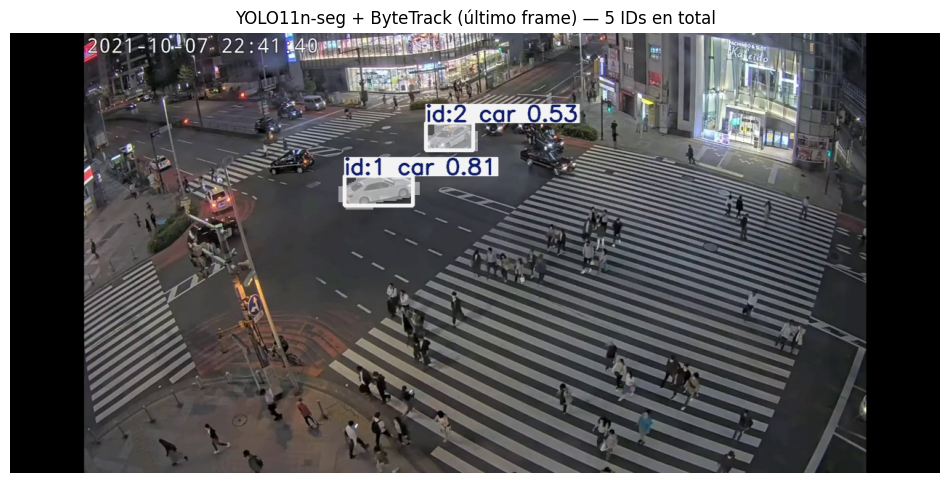

In [57]:
device = list(DEVICES.values())[-1]   # usa GPU si hay, si no CPU
n_ids, tracks_pf, vis = trackear("bytetrack.yaml", device=device)
print(f"ByteTrack — IDs únicos en {N_FRAMES} frames: {n_ids}")

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title(f"YOLO11n-seg + ByteTrack (último frame) — {n_ids} IDs en total")
plt.show()

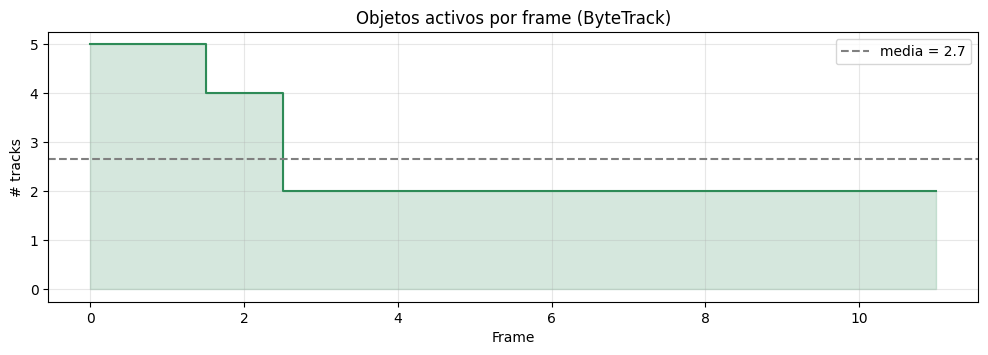

In [58]:
# Objetos activos por frame
plt.figure(figsize=(12, 3.5))
plt.step(range(len(tracks_pf)), tracks_pf, where="mid", color="seagreen")
plt.fill_between(range(len(tracks_pf)), tracks_pf, step="mid", alpha=0.2, color="seagreen")
plt.axhline(np.mean(tracks_pf), ls="--", color="gray",
            label=f"media = {np.mean(tracks_pf):.1f}")
plt.title("Objetos activos por frame (ByteTrack)")
plt.xlabel("Frame"); plt.ylabel("# tracks"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

#### Análisis

Cada caja ahora lleva un número de **ID** además de la clase. Si el tracking fuera perfecto,
la cantidad de IDs únicos sería igual a la cantidad real de objetos distintos que pasaron por
la escena. En la práctica, las **oclusiones** y los **cambios de escala** hacen que a veces un
mismo objeto reciba un ID nuevo (un *ID switch*), inflando el conteo de IDs únicos.

El gráfico de **objetos activos por frame** sigue la complejidad de la escena: sube cuando hay
más gente/autos en cuadro. Comparalo con la curva de latencia del bloque 2 — suelen estar
correlacionadas (más objetos ⇒ más trabajo de post-procesado ⇒ frames más lentos).

---
# 4. SAM3 — probándolo de verdad

En la teoría vimos **SAM3** (Segment Anything Model 3, Meta). A diferencia de YOLO, SAM3 es un
modelo de **segmentación de vocabulario abierto**: le pasás los conceptos que querés segmentar
como **texto** (por ejemplo `"person"`, `"car"`) y produce máscaras densas de muy alta calidad
con un encoder **ViT** que procesa la imagen a 1008×1008.

| | **YOLO11-seg** | **SAM3** |
|---|---|---|
| Filosofía | máscaras livianas ancladas a la caja | máscaras densas de un encoder ViT |
| Clases | fijas (80 de COCO) | **vocabulario abierto** (prompts de texto) |
| Calidad de máscara | buena | **excelente** (bordes finos) |
| Velocidad (GPU) | ~20–45 ms/frame (tiempo real) | **~1500 ms/frame** (~30× más lento) |
| Acceso a pesos | abiertos (se bajan solos) | *gated* (requiere token de Hugging Face) |

> ⚠️ **SAM3 es lento** (~1–2 s/frame). Para que la práctica no demore, acá procesamos
> **pocos frames** (`SAM_FRAMES`). Aun así, alcanza para ver la diferencia con YOLO.

## 4.1 Descargar los pesos (modelo *gated*)

SAM3 requiere aceptar la licencia y un **token de Hugging Face**:

1. Aceptá la licencia en **https://huggingface.co/facebook/sam3**
2. Generá un token en **https://huggingface.co/settings/tokens**
3. En Colab, guardalo como secreto **`HF_TOKEN`** (panel 🔑 a la izquierda) y activalo para este
   notebook. Localmente, podés exportarlo como variable de entorno `HF_TOKEN`.

In [59]:
import os
from huggingface_hub import hf_hub_download

# Buscar el token: primero en los secretos de Colab, si no en variables de entorno
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

sam3_path = None
try:
    sam3_path = hf_hub_download(repo_id="facebook/sam3", filename="sam3.pt",
                                local_dir=".", token=HF_TOKEN)
    print("✅ Pesos de SAM3 descargados en:", sam3_path)
except Exception as e:
    print("⚠️  No se pudieron descargar los pesos de SAM3.")
    print("   SAM3 es un modelo *gated*: aceptá la licencia en")
    print("   https://huggingface.co/facebook/sam3 y generá un token en")
    print("   https://huggingface.co/settings/tokens (guardalo como HF_TOKEN).")
    print("   Detalle:", e)

c:\Users\const\Documents\Trabajo\Facultad\CV\IA5.2_Computer_Vision\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⚠️  No se pudieron descargar los pesos de SAM3.
   SAM3 es un modelo *gated*: aceptá la licencia en
   https://huggingface.co/facebook/sam3 y generá un token en
   https://huggingface.co/settings/tokens (guardalo como HF_TOKEN).
   Detalle: 401 Client Error. (Request ID: Root=1-6a1d6c80-17a4d9b85a86b8c4255b2edd;0f5750de-5a20-4ed3-a4ea-0e70642f4e69)

Cannot access gated repo for url https://huggingface.co/facebook/sam3/resolve/main/sam3.pt.
Access to model facebook/sam3 is restricted. You must have access to it and be authenticated to access it. Please log in.


## 4.2 Métricas por frame con *hooks*

SAM3 se corre con un **predictor de video** (`SAM3VideoSemanticPredictor`). Para medirlo,
registramos un *callback* que se ejecuta al final de cada frame y va guardando la latencia,
la cantidad de máscaras y las instancias por clase — el mismo patrón que usa la teoría.

In [60]:
def get_cpu_ram_mb():
    """RAM del proceso actual en MB."""
    return psutil.Process().memory_info().rss / 1e6

def get_gpu_memory_mb():
    """VRAM reservada en MB (0 si no hay CUDA)."""
    return torch.cuda.memory_allocated() / 1e6 if HAS_CUDA else 0.0


class ResourceMonitor:
    """Acumula métricas por frame durante la inferencia de SAM3."""
    def __init__(self):
        self.inference_ms = []
        self.n_masks = []
        self.names = []
        self.instances_by_class = []
        self.vram_mb = []

    def summary(self):
        lat = np.array(self.inference_ms)
        return {
            "mean_ms":      float(lat.mean()),
            "p95_ms":       float(np.percentile(lat, 95)),
            "fps":          float(1000.0 / lat.mean()),
            "mean_masks":   float(np.mean(self.n_masks)),
            "peak_vram_mb": float(np.max(self.vram_mb)) if self.vram_mb else 0.0,
        }


def make_hook(monitor):
    """Callback registrado en 'on_predict_batch_end': corre tras cada frame."""
    def hook(predictor):
        r = predictor.results[0]
        counts = {}
        if r.boxes is not None:
            for clsid in r.boxes.cls:
                clsid = int(clsid)
                counts[clsid] = counts.get(clsid, 0) + 1
        monitor.inference_ms.append(r.speed["inference"])
        monitor.n_masks.append(len(r.masks) if r.masks is not None else 0)
        monitor.names.append(r.names)
        monitor.instances_by_class.append(counts)
        monitor.vram_mb.append(get_gpu_memory_mb())
    return hook

## 4.3 Inferencia

Construimos el predictor, le pasamos los **prompts de texto** (`["person", "car"]`) y recorremos
unos pocos frames en modo *stream* (un frame por iteración).

In [61]:
from ultralytics.models.sam import SAM3VideoSemanticPredictor

assert sam3_path, "Primero descargá los pesos de SAM3 (celda 4.1)."

# SAM3 es lento (~1-2 s/frame en GPU, y mucho más en CPU): procesamos pocos frames.
SAM_FRAMES = 20 if HAS_CUDA else 3

overrides = dict(
    conf=0.5,
    task="segment",
    mode="predict",
    model=sam3_path,
    half=HAS_CUDA,   # FP16 solo en GPU
    save=False,
)
try:
    del predictor
except NameError:
    pass
predictor = SAM3VideoSemanticPredictor(overrides=overrides)

monitor = ResourceMonitor()
predictor.add_callback("on_predict_batch_end", make_hook(monitor))

stream = predictor(source=VIDEO_PATH, text=["person", "car"], stream=True)
print(f"Procesando {SAM_FRAMES} frames con SAM3 (esto puede tardar)...")
t0 = time.perf_counter()
for i, r in enumerate(stream):
    if i + 1 >= SAM_FRAMES:
        break
print(f"Listo: {len(monitor.inference_ms)} frames en {time.perf_counter()-t0:.1f} s")

AssertionError: Primero descargá los pesos de SAM3 (celda 4.1).

## 4.4 Latencia de inferencia

In [ ]:
def smooth(x, w=5):
    return np.convolve(x, np.ones(w) / w, mode="valid")

ms = np.array(monitor.inference_ms)
xs = np.arange(len(ms))

plt.figure(figsize=(13, 4))
plt.fill_between(xs, ms, alpha=0.15, color="steelblue")
plt.plot(xs, ms, color="steelblue", alpha=0.4, lw=0.8, label="SAM3 raw")
if len(ms) >= 5:
    plt.plot(np.arange(len(smooth(ms))), smooth(ms), color="steelblue", lw=2, label="suavizado")
plt.axhline(ms.mean(), ls="--", color="crimson", lw=1.4, label=f"media = {ms.mean():.0f} ms")
plt.title(f"SAM3 — latencia por frame ({'GPU' if HAS_CUDA else 'CPU'})")
plt.xlabel("Frame"); plt.ylabel("ms"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

s = monitor.summary()
print(f"SAM3: media={s['mean_ms']:.0f} ms | P95={s['p95_ms']:.0f} ms | "
      f"{s['fps']:.2f} FPS | máscaras/frame={s['mean_masks']:.1f}")

#### Análisis

La latencia de SAM3 vive en el rango de los **~1000–2500 ms por frame**, dos órdenes de
magnitud por encima de YOLO11n. La curva es **consistente** (banda angosta): SAM3 siempre es
lento, pero de forma predecible, y la variación que hay sigue la complejidad de la escena.

¿Por qué es tan lento? Su cuello de botella es el **encoder ViT** que hace *self-attention*
global sobre una imagen de 1008×1008. La atención escala **cuadráticamente** con la cantidad de
parches, y ese patrón de acceso a memoria aprovecha mucho menos el paralelismo de la GPU que las
convoluciones de YOLO — por eso la GPU "no rescata" a SAM3 como sí lo hace con YOLO.

## 4.5 Máscaras e instancias por clase

In [ ]:
# Máscaras por frame
vals = np.array(monitor.n_masks)
plt.figure(figsize=(13, 3.5))
plt.step(range(len(vals)), vals, where="mid", color="purple")
plt.fill_between(range(len(vals)), vals, step="mid", alpha=0.15, color="purple")
plt.axhline(vals.mean(), ls="--", color="gray", label=f"media = {vals.mean():.1f}")
plt.title("SAM3 — máscaras detectadas por frame")
plt.xlabel("Frame"); plt.ylabel("# máscaras"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Instancias por frame y clase (barras apiladas)
filas = []
for i, (counts, names) in enumerate(zip(monitor.instances_by_class, monitor.names)):
    for cid, n in counts.items():
        nombre = names[cid] if isinstance(names, dict) and cid in names else str(cid)
        filas.append({"frame": i, "clase": nombre, "n": n})

df_cls = pd.DataFrame(filas)
if not df_cls.empty:
    piv = df_cls.pivot_table(index="frame", columns="clase", values="n",
                             aggfunc="sum").fillna(0)
    piv.plot(kind="bar", stacked=True, figsize=(14, 5), width=1.0,
             color={"person": "#E8643C", "car": "#4C9BE8"})
    plt.title("SAM3 — instancias por frame y clase")
    plt.xlabel("Frame"); plt.ylabel("# instancias"); plt.legend(title="Clase")
    plt.tight_layout(); plt.show()

#### Análisis

SAM3 segmenta **muchas más instancias por frame** que YOLO (en la teoría: ~37 de media contra
~14 de YOLO11x). Al ser un segmentador de regiones coherentes guiado por los prompts, captura
objetos pequeños y parcialmente ocluidos que YOLO descarta. El conteo por clase vuelve a seguir
la complejidad de la escena: los **autos** suelen ser estables (siempre hay en cuadro) y las
**personas** generan casi toda la variación.

---
# 5. Comparación final: YOLO11 vs SAM3

Juntamos las métricas de YOLO11n (bloque 2) y SAM3 (bloque 4) en un mismo gráfico.
Ojo con la **escala logarítmica** en latencia: sin ella, las barras de YOLO ni se verían.

In [ ]:
sam = monitor.summary()
comp = {f"YOLO11n ({label})": {"mean_ms": r["mean_ms"], "fps": r["fps"]}
        for label, r in results.items()}
comp[f"SAM3 ({'GPU' if HAS_CUDA else 'CPU'})"] = {"mean_ms": sam["mean_ms"], "fps": sam["fps"]}

dfc = pd.DataFrame(comp).T

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(dfc.index, dfc["mean_ms"], color="#4C9BE8")
axes[0].set_yscale("log"); axes[0].set_ylabel("ms (log)")
axes[0].set_title("Latencia media por frame")
axes[1].bar(dfc.index, dfc["fps"], color="#F2A541")
axes[1].set_ylabel("FPS"); axes[1].set_title("Throughput (FPS)")
for ax in axes:
    ax.tick_params(axis="x", rotation=20); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

dfc.round(2)

#### Análisis

- **SAM3 corre en GPU pero queda en el orden de YOLO11x en CPU** (~0.7 FPS): la GPU acelera
  enormemente a YOLO (de >1 s a decenas de ms) pero apenas mueve la aguja de SAM3.
- **No compiten**: resuelven problemas distintos. YOLO11 es *class-aware*, rápido y con máscaras
  "suficientemente buenas"; SAM3 es exhaustivo y de altísima fidelidad, pero paga ~30× en latencia.
- La lección de fondo: **más GPU no arregla un desajuste arquitectónico**. Para video en vivo se
  usa YOLO; SAM3 brilla offline o combinado (YOLO detecta rápido y SAM refina donde importa).

---
# Ejercicios

Cada ejercicio tiene una celda con el código comentado como guía.
Descomentá, completá los huecos y ejecutá.

## Ejercicio 1 — ¿Cuánto cuesta un modelo más grande?

YOLO11-seg viene en varios tamaños: `n` (nano), `s`, `m`, `l`, `x` (extra-large).
Corré el benchmark con **`yolo11m-seg.pt`** y compará contra `yolo11n-seg.pt`.

1. Llamá a `benchmark("yolo11m-seg.pt", device)` para cada dispositivo de `DEVICES`
2. Imprimí media de latencia y FPS
3. Respondé: ¿cuántas veces más lento es `m` que `n`? ¿La diferencia es igual en CPU que en GPU?

> **Tip:** la primera vez se descargan los pesos de `yolo11m-seg` (es más pesado que `n`).

In [ ]:
# Ejercicio 1 — completar aquí

# for label, device in DEVICES.items():
#     r = benchmark("yolo11m-seg.pt", device)
#     print(f"{label}: media={r['mean_ms']:.1f} ms | {r['fps']:.1f} FPS")

# Comparar con results['CPU'] / results['GPU'] (yolo11n) calculados en el bloque 2

## Ejercicio 2 — ByteTrack vs BoT-SORT

Volvé a trackear pero ahora con **`botsort.yaml`** y compará con ByteTrack.

1. Llamá a `trackear("botsort.yaml", device=device)`
2. Compará el número de IDs únicos y la curva de tracks por frame contra ByteTrack
3. Respondé: ¿da más o menos IDs? Recordá que BoT-SORT usa apariencia (ReID) y compensación
   de cámara — ¿esperarías **menos** *ID switches* en escenas con oclusiones?

In [ ]:
# Ejercicio 2 — completar aquí

# n_ids_bot, tracks_bot, vis_bot = trackear("botsort.yaml", device=device)
# print(f"BoT-SORT  — IDs únicos: {n_ids_bot}")
# print(f"ByteTrack — IDs únicos: {n_ids}")

# Opcional: graficar las dos curvas de tracks por frame superpuestas

## Ejercicio 3 — Efecto del tamaño de entrada (`imgsz`)

YOLO redimensiona cada frame a `imgsz × imgsz` antes de inferir. Un `imgsz` más grande
detecta mejor los objetos chicos, pero cuesta más (la latencia crece ~cuadráticamente).

1. Corré `benchmark("yolo11n-seg.pt", device, imgsz=320)` y `imgsz=1280`
2. Compará latencia media y **máscaras detectadas por frame** (`mean_masks`)
3. Respondé: ¿con `imgsz` grande se detectan más objetos? ¿Cuánto más caro sale?

> **Tip:** `imgsz` debe ser múltiplo de 32.

In [ ]:
# Ejercicio 3 — completar aquí

# for size in (320, 1280):
#     r = benchmark("yolo11n-seg.pt", device, imgsz=size)
#     print(f"imgsz={size}: media={r['mean_ms']:.1f} ms | "
#           f"máscaras/frame={r['mean_masks']:.1f}")

## Ejercicio 4 — Segmentar solo una clase

A veces solo nos interesan ciertos objetos (por ejemplo, **personas**). YOLO permite filtrar
por clase con el parámetro `classes` (en COCO, la clase `0` es *person* y la `2` es *car*).

1. Tomá el primer frame del video (como en el bloque 1)
2. Corré `model(frame, conf=0.3, classes=[0], verbose=False)[0]`
3. Visualizá el resultado con `res.plot()` y contá cuántas personas hay
4. (Opcional) Probá `classes=[2]` (*car*) y compará

> **Tip:** podés ver el mapeo id→clase con `model.names`.

In [ ]:
# Ejercicio 4 — completar aquí

# cap = cv2.VideoCapture(VIDEO_PATH); ok, frame = cap.read(); cap.release()
# res = model(frame, conf=0.3, classes=[0], verbose=False)[0]
# print("Personas:", len(res.masks) if res.masks is not None else 0)
# plt.figure(figsize=(12, 6))
# plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

## Ejercicio 5 — Guardar el video anotado

Hasta ahora visualizamos frames sueltos. Generá un **video de salida** con las máscaras y los
IDs dibujados, para poder reproducirlo después.

1. Abrí el video con `cv2.VideoCapture` y creá un `cv2.VideoWriter` (mismo `W`, `H`, `FPS_SRC`)
2. Para cada frame, corré `model.track(..., persist=True)` y obtené `r.plot()`
3. Escribí cada frame anotado con `writer.write(...)` y al final `writer.release()`
4. (En Colab) descargá el archivo con `from google.colab import files; files.download(...)`

> **Tip:** el codec `cv2.VideoWriter_fourcc(*"mp4v")` y la extensión `.mp4` funcionan bien.

In [ ]:
# Ejercicio 5 — completar aquí

# out_path = "salida_tracking.mp4"
# writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), FPS_SRC, (W, H))
# model = YOLO("yolo11n-seg.pt")
# cap = cv2.VideoCapture(VIDEO_PATH)
# for _ in range(N_FRAMES):
#     ok, frame = cap.read()
#     if not ok: break
#     r = model.track(frame, persist=True, tracker="bytetrack.yaml",
#                     device=device, conf=0.3, verbose=False)[0]
#     writer.write(r.plot())
# cap.release(); writer.release()
# print("Guardado en", out_path)

## Ejercicio 6 — Vocabulario abierto de SAM3

SAM3 segmenta lo que le pidas por **texto**, sin estar limitado a las 80 clases de COCO.
Volvé a correr SAM3 cambiando los prompts.

1. Reusá el `predictor` y el patrón del bloque 4.3, pero con otros prompts:
   por ejemplo `text=["bus", "traffic light", "bicycle"]`
2. Procesá unos pocos frames y mirá las máscaras con `r.plot()`
3. Respondé: ¿segmenta bien conceptos que **no** son clases típicas de YOLO?

> **Tip:** podés probar conceptos más abstractos (`"road"`, `"building"`) y ver hasta dónde llega.

In [ ]:
# Ejercicio 6 — completar aquí

# stream = predictor(source=VIDEO_PATH, text=["bus", "traffic light", "bicycle"], stream=True)
# for i, r in enumerate(stream):
#     if i >= 3: break
#     plt.figure(figsize=(12, 6))
#     plt.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)); plt.axis("off")
#     plt.title(f"SAM3 — frame {i}"); plt.show()

---
# Conclusiones

- **Segmentación de instancias** = una máscara por objeto, no solo una caja. YOLO11-seg la
  produce en tiempo real entregando `boxes`, `masks`, `conf` y `names` por frame.
- El **hardware no cambia qué se detecta, solo qué tan rápido**: en GPU el mismo modelo corre
  muchas veces más rápido y con latencia más predecible (P95 ≈ media); los modelos grandes son
  los que más se benefician.
- El **tracking** agrega memoria temporal (IDs persistentes) combinando **Kalman + Húngaro**;
  **ByteTrack** prioriza velocidad y **BoT-SORT** robustez ante oclusiones y cámara en movimiento.
- **SAM3** es otra clase de modelo: vocabulario abierto y máscaras de altísima calidad, pero
  ~30× más lento. La GPU no lo rescata porque su cuello de botella es la atención ViT, no las
  convoluciones. **No compite** con YOLO: resuelven problemas distintos.

| Prioridad | Elección sugerida |
|---|---|
| Tiempo real en GPU | `yolo11n/m-seg` |
| Máxima precisión (offline) | `yolo11x-seg` o SAM3 |
| Cámara estática, multitud | ByteTrack |
| Cámara en movimiento / oclusiones largas | BoT-SORT |
| Máscaras de altísima calidad / vocabulario abierto | SAM3 (lento, no tiempo real) |

**Conceptos clave de esta práctica:** segmentación de instancias vs. semántica · latencia,
P95 y throughput (FPS) · speedup CPU→GPU · tracking por detección con Kalman + algoritmo Húngaro
· ByteTrack vs. BoT-SORT · YOLO vs. SAM3 (velocidad vs. calidad) · vocabulario abierto.